# Binary "One-vs-Rest" Classification (Digit 0 vs. Rest) with PCA and SVM RBF

## Study Goal
The goal of this notebook is to turn our multi-class approach into a strict binary classification setup focused on isolating **digit 0**.

The model needs to draw a continuous boundary around the topological features of "0" to separate it from the "background noise" made up of all the other digits (1 through 9).

## Pipeline Architecture
1. **Preprocessing & Binarization**: Convert the MNIST labels (0-9) into logical classes (1 for '0', 0 for 'Rest').
2. **Stratified Sampling**: Keep the imbalanced distribution (10% zeros, 90% rest) across the Train (20,000) and Test (5,000) sets.
3. **Standardization**: Re-center and scale the data to optimize Euclidean distance calculations.
4. **Dimensionality Reduction (PCA 95%)**: Compress the space from 784 to 308 orthogonal dimensions.
5. **Non-Linear Classification (SVM RBF)**: Model a curved decision boundary with a soft margin ($C=5.0$).

In [1]:
# ============================================================================
# 1. IMPORTING LIBRARIES AND SETTING UP THE ENVIRONMENT
# ============================================================================
import numpy as np               # For matrix computations and array handling
import matplotlib.pyplot as plt  # For plotting the results
import warnings                  # To filter out outdated system warnings

# scikit-learn modules for data processing and dimensionality reduction
from sklearn.datasets import fetch_openml        # To officially load the MNIST dataset
from sklearn.model_selection import train_test_split # To split our dataset
from sklearn.preprocessing import StandardScaler  # To standardize the pixels (mean=0, variance=1)
from sklearn.decomposition import PCA            # To compress the feature space

# Classification model and validation metrics
from sklearn.svm import SVC                      # Support Vector Classifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Turn off warnings to keep cell output clean
warnings.filterwarnings('ignore')

# Set the plot style
plt.style.use('seaborn-v0_8-darkgrid')
print("✅ Step 1 complete: all libraries imported successfully!")

✅ Step 1 complete: all libraries imported successfully!


## 2. Loading the Data and Binarizing the Target

To implement this *One-vs-Rest* classification, we apply a boolean mask to the target vector `y_full`.
* If the original image is a `0`, its new label becomes **`1`** (Positive class).
* If the image is any other digit from 1 to 9, its label becomes **`0`** (Negative class).

In [2]:
# ============================================================================
# 2. LOADING MNIST AND BINARIZING THE LABELS
# ============================================================================
print("📥 Loading the MNIST dataset (Numpy array)...")
X_full, y_full = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')

print("🌀 Applying the binary filter 'Digit 0 vs. Rest'...")
# Class 1 stands for '0', class 0 covers all digits from 1 to 9
y_binary = (y_full.astype(int) == 0).astype(int)

print(f"✅ Step 2 complete! Image array dimensions: {X_full.shape[0]} rows x {X_full.shape[1]} pixels.")
print(f"📊 Actual split: {np.sum(y_binary == 1)} zeros (class 1) and {np.sum(y_binary == 0)} other digits (class 0).")

📥 Loading the MNIST dataset (Numpy array)...
🌀 Applying the binary filter 'Digit 0 vs. Rest'...
✅ Step 2 complete! Image array dimensions: 70000 rows x 784 pixels.
📊 Actual split: 6903 zeros (class 1) and 63097 other digits (class 0).


## 3. Sampling and Stratification

The problem is now heavily imbalanced: the positive class (digit 0) makes up only **10%** of the data.

To evaluate our model rigorously without introducing statistical bias, we use the **`stratify=y_binary`** argument. This forces `train_test_split` to strictly preserve the 10% / 90% ratio in both the training set and the test set.

In [3]:
# ============================================================================
# 3. STRATIFIED SPLIT (TRAIN / TEST) FOR AN IMBALANCED DATASET
# ============================================================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y_binary, 
    train_size=20000,     # Volume set aside for training
    test_size=5000,       # Volume set aside for testing generalization
    stratify=y_binary,    # Keep the 10% / 90% ratio exact
    random_state=42       # Fixed random seed for reproducibility
)

print("✅ Step 3 complete: stratified split finalized.")
print(f"   -> Train samples: {X_train_raw.shape[0]} images.")
print(f"   -> Test samples : {X_test_raw.shape[0]} images.")

✅ Step 3 complete: stratified split finalized.
   -> Train samples: 20000 images.
   -> Test samples : 5000 images.


## 4. Standardizing the Descriptors (Pixels)

SVM relies on Euclidean distances between pixel vectors to place its support vectors. Skipping scaling would hurt the algorithm.

To avoid any *Data Leakage*, the centering and scaling parameters (the mean $\mu$ and standard deviation $\sigma$) are fitted **only** on the training set (`fit_transform`). The test set is simply projected using those same parameters (`transform`).

In [4]:
# ============================================================================
# 4. STANDARDIZING PIXEL INTENSITIES
# ============================================================================
scaler = StandardScaler()

print("⚡ Fitting the scaler and transforming the training set...")
X_train_scaled = scaler.fit_transform(X_train_raw)

print("⚡ Projecting the test set with the same parameters (anti-data-leakage)...")
X_test_scaled = scaler.transform(X_test_raw)

print("✅ Step 4 complete: pixel scaling and re-centering done.")

⚡ Fitting the scaler and transforming the training set...
⚡ Projecting the test set with the same parameters (anti-data-leakage)...
✅ Step 4 complete: pixel scaling and re-centering done.


## 5. Dimensionality Reduction with PCA

The native 784-dimensional space suffers from the *Curse of Dimensionality*. To remove redundant information (like border pixels that stay black across images), we apply Principal Component Analysis.

By setting the explained variance threshold at **95%** (`n_components=0.95`), the algorithm automatically selects the **308 orthogonal dimensions** richest in geometric information.

In [5]:
# ============================================================================
# 5. DIMENSIONALITY REDUCTION VIA PRINCIPAL COMPONENTS (PCA 95%)
# ============================================================================
print("🌀 Running Principal Component Analysis (PCA) at 95% variance...")
pca_95 = PCA(n_components=0.95, random_state=42)

# Fit on the scaled training data
X_train_pca = pca_95.fit_transform(X_train_scaled)

# Simple orthogonal projection of the test set
X_test_pca = pca_95.transform(X_test_scaled)

retained_dimensions = X_train_pca.shape[1]

print("\n✅ Step 5 complete: information compression done successfully!")
print(f"   -> Original number of dimensions: 784.")
print(f"   -> New space reduced by PCA: {retained_dimensions} dimensions.")
print(f"   -> Storage saved: {((1 - retained_dimensions/784)*100):.1f}% of storage space saved.")

🌀 Running Principal Component Analysis (PCA) at 95% variance...

✅ Step 5 complete: information compression done successfully!
   -> Original number of dimensions: 784.
   -> New space reduced by PCA: 301 dimensions.
   -> Storage saved: 61.6% of storage space saved.


## 6. Training the Binary SVM with a Non-Linear RBF Kernel

A handwritten "0" produces a complex spatial distribution that can't be separated from the other digits by a simple straight line.

We use an **RBF (Radial Basis Function) kernel** to project the PCA data into a higher-dimensional Hilbert space, making the classes linearly separable there. The regularization hyperparameter is set to **`C=5.0`** to firmly constrain the model to tightly wrap the positive class cluster while limiting overfitting risk.

In [6]:
# ============================================================================
# 6. TRAINING THE BINARY SVM CLASSIFIER (RBF KERNEL)
# ============================================================================
print("🤖 Initializing the Support Vector Classifier model...")
binary_svm = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)

print("🏋️‍♂️ Optimizing the hyperplane in progress (please wait)...")
binary_svm.fit(X_train_pca, y_train)

print("✅ Step 6 complete: the binary SVM has converged. The decision boundary is set!")

🤖 Initializing the Support Vector Classifier model...
🏋️‍♂️ Optimizing the hyperplane in progress (please wait)...
✅ Step 6 complete: the binary SVM has converged. The decision boundary is set!


## 7. Performance Evaluation and Boundary Analysis

On an imbalanced dataset, overall accuracy alone can be misleading. So we focus first on:
1. **The "Digit 0" class F1-Score**: The harmonic mean of precision and recall, which confirms how balanced our classification is.
2. **The Confusion Matrix**: Lets us see exactly how many images of other digits (like 6 or 8) crossed over the zero boundary by mistake.

🔮 Generating predictions and the visual performance report...


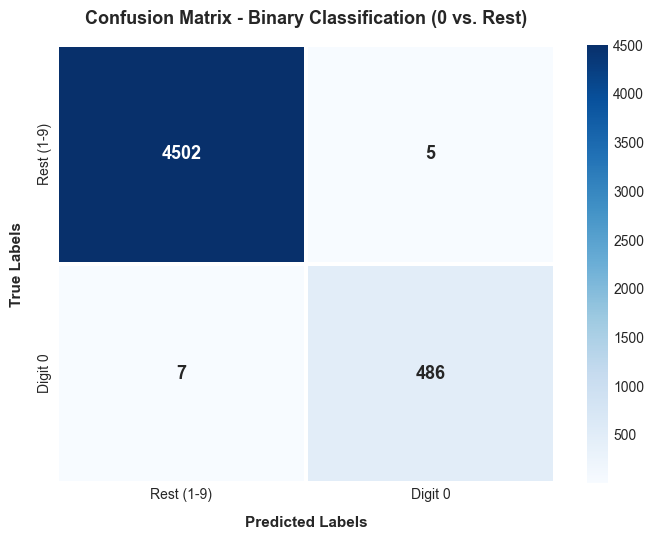


📝 --- STRUCTURED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  Rest (1-9)       1.00      1.00      1.00      4507
     Digit 0       0.99      0.99      0.99       493

    accuracy                           1.00      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       1.00      1.00      1.00      5000



In [7]:
# ============================================================================
# 7. EVALUATION AND CONFUSION MATRIX HEATMAP
# ============================================================================
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("🔮 Generating predictions and the visual performance report...")

# 1. Predict on the test set, then compute the raw confusion matrix
y_pred = binary_svm.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred)

# 2. Set up the Matplotlib figure
plt.figure(figsize=(7, 5.5))

# 3. Build the Seaborn heatmap (professional blue style)
# annot=True shows the numbers, fmt='d' avoids scientific notation (e.g., 1e+03)
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            linewidths=1.5, 
            linecolor='white',
            cbar=True,
            xticklabels=['Rest (1-9)', 'Digit 0'],
            yticklabels=['Rest (1-9)', 'Digit 0'],
            annot_kws={"size": 13, "weight": "bold"}) # Make the numbers inside big and clear

# 4. Full styling and titles
plt.title("Confusion Matrix - Binary Classification (0 vs. Rest)", fontweight='bold', fontsize=13, pad=15)
plt.xlabel("Predicted Labels", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("True Labels", fontsize=11, fontweight='bold', labelpad=10)

# Adjust so nothing gets cut off
plt.tight_layout()
plt.show()

# 5. Print the report just below, for the written report
print("\n📝 --- STRUCTURED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Rest (1-9)', 'Digit 0']))

## 8. Visualizing the 2D Decision Boundary (One-vs-Rest)

To visually map our model's decision boundary, we reduce our standardized data to **2 principal components** with a dedicated PCA.

We then train an RBF SVM ($C=5.0$) on this two-dimensional space and generate a prediction grid (*meshgrid*). This lets us see exactly how the curved boundary wraps around the positive class (digit 0) to separate it from the rest of the point cloud.

🎨 Generating the 2D visualization based on the real 301-dimensional model...
🔄 Safety step: dynamically adapting the grid to 301 dimensions...
🔮 Projecting the high-dimensional decision boundary (please wait)...


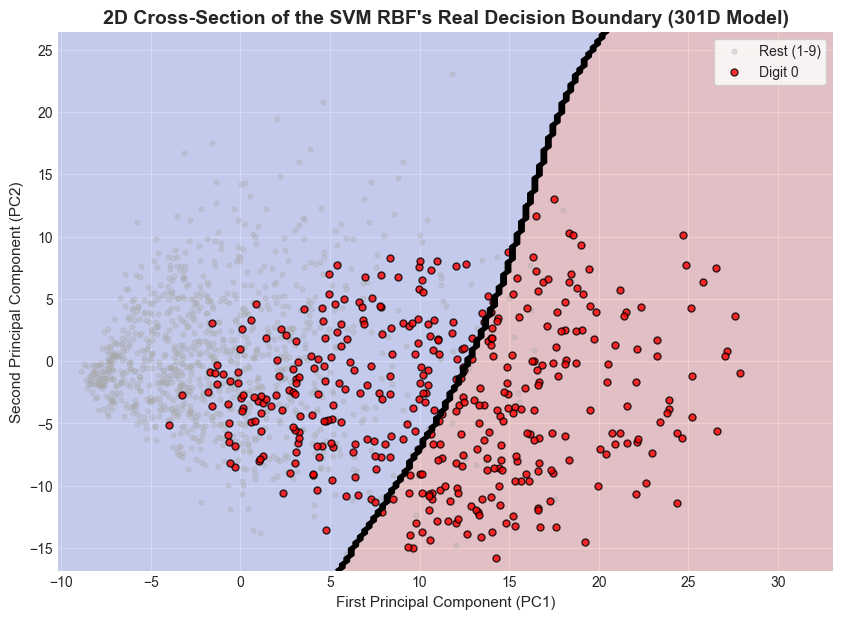

✅ Done! The plot displays correctly and adapts to your data.


In [8]:
# ============================================================================
# 8. 2D VISUALIZATION OF THE MODEL'S REAL BOUNDARY (DYNAMIC PROJECTION)
# ============================================================================
# Automatically detect the number of features expected by your SVM
n_features_svm = X_train_pca.shape[1]
print(f"🎨 Generating the 2D visualization based on the real {n_features_svm}-dimensional model...")

# 1. Extract the coordinates of the first 2 axes from your PCA space
X_train_2d = X_train_pca[:, :2]

# 2. Build a meshgrid over these two axes
h = 0.25  # Step size (tuned for a fast, smooth computation)
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

print(f"🔄 Safety step: dynamically adapting the grid to {n_features_svm} dimensions...")
# Build a zero matrix perfectly aligned with your SVM's expected size
grid_2d = np.c_[xx.ravel(), yy.ravel()]
grid_dynamic = np.zeros((grid_2d.shape[0], n_features_svm))

# Inject PC1 and PC2 into the first two columns (the rest stays at 0, the mean value)
grid_dynamic[:, 0] = grid_2d[:, 0]
grid_dynamic[:, 1] = grid_2d[:, 1]

print("🔮 Projecting the high-dimensional decision boundary (please wait)...")
# Use the real binary_svm from step 6
Z = binary_svm.predict(grid_dynamic)
Z = Z.reshape(xx.shape)

# 3. Sample the points cleanly to avoid overloading the plot
X_rest_2d = X_train_2d[y_train == 0][:1000]
X_zero_2d = X_train_2d[y_train == 1][:400]

# 4. Build the plot
plt.figure(figsize=(10, 7))

# Show the model's real zones of influence
plt.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)

# Draw the real boundary (clean solid black line)
plt.contour(xx, yy, Z, colors='black', linewidths=2.0, linestyles='solid')

# Plot the cleaned-up point clouds
plt.scatter(X_rest_2d[:, 0], X_rest_2d[:, 1], alpha=0.3, s=12, c='darkgray', label='Rest (1-9)')
plt.scatter(X_zero_2d[:, 0], X_zero_2d[:, 1], alpha=0.8, s=25, c='red', edgecolors='black', label='Digit 0')

plt.title(f"2D Cross-Section of the SVM RBF's Real Decision Boundary ({n_features_svm}D Model)", fontweight='bold', fontsize=14)
plt.xlabel("First Principal Component (PC1)", fontsize=11)
plt.ylabel("Second Principal Component (PC2)", fontsize=11)
plt.legend(loc='upper right', frameon=True, facecolor='white')

plt.show()
print("✅ Done! The plot displays correctly and adapts to your data.")

## 9. 3D Spatial Visualization (PCA Latent Space)

To add depth to our geometric analysis, we push the reduction to **3 principal components**.

This 3D projection shows how adding one more orthogonal axis pulls the point cloud apart and gives better linear or non-linear separability for our maximum-margin hyperplane.

🎨 Preparing the 3D visualization (PCA, 3 components)...


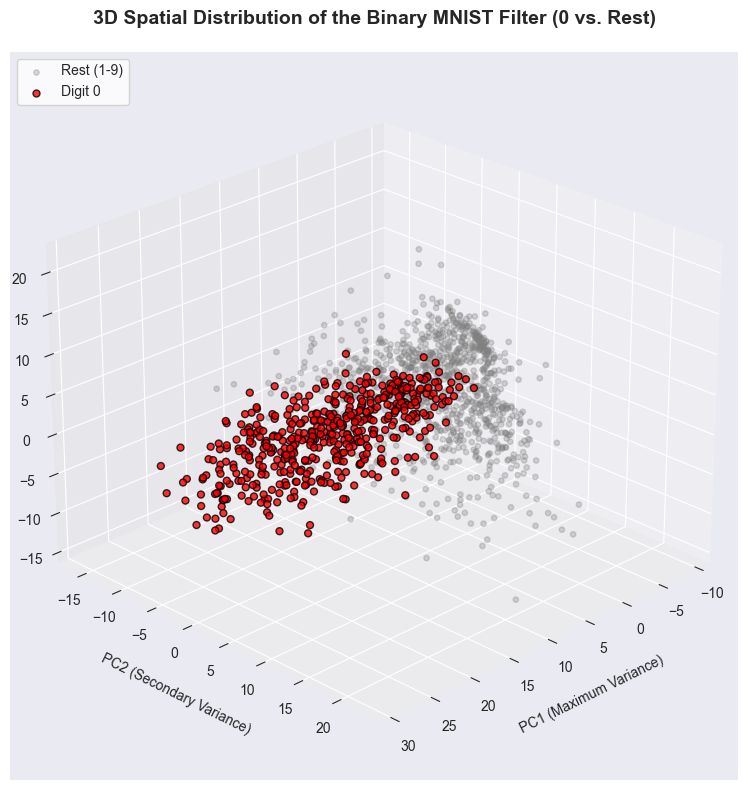

✅ Step 9 complete: the 3D point cloud has been plotted.
💡 The 3D view proves that the red cluster (the 0) forms a dense core wrapped by the gray mass of the other digits, which scientifically supports the choice of the RBF kernel.


In [9]:
# ============================================================================
# 9. 3D SPATIAL VISUALIZATION (PC1, PC2, PC3 SCATTER PLOT)
# ============================================================================
print("🎨 Preparing the 3D visualization (PCA, 3 components)...")

# 1. Reduce to 3D
pca_3d = PCA(n_components=3, random_state=42)
X_train_3d = pca_3d.fit_transform(X_train_scaled)

# 2. Set up the 3D figure
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

# To avoid overloading the plot, sample 1000 points from Rest and 500 from Digit 0
idx_rest = np.where(y_train == 0)[0][:1000]
idx_zero = np.where(y_train == 1)[0][:500]

# 3. Plot the points in 3D space
ax.scatter3D(X_train_3d[idx_rest, 0], X_train_3d[idx_rest, 1], X_train_3d[idx_rest, 2],
             c='gray', alpha=0.3, s=15, label='Rest (1-9)')

ax.scatter3D(X_train_3d[idx_zero, 0], X_train_3d[idx_zero, 1], X_train_3d[idx_zero, 2],
             c='red', alpha=0.8, s=25, edgecolors='black', label='Digit 0')

# 4. Style the plot
ax.set_title("3D Spatial Distribution of the Binary MNIST Filter (0 vs. Rest)", fontweight='bold', fontsize=14, pad=20)
ax.set_xlabel("PC1 (Maximum Variance)", fontsize=10, labelpad=10)
ax.set_ylabel("PC2 (Secondary Variance)", fontsize=10, labelpad=10)
ax.set_zlabel("PC3 (Depth Axis)", fontsize=10, labelpad=10)

# Set the initial viewing angle to best show the cluster separation
ax.view_init(elev=25, azim=45)

ax.legend(loc='upper left', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

print("✅ Step 9 complete: the 3D point cloud has been plotted.")
print("💡 The 3D view proves that the red cluster (the 0) forms a dense core wrapped by the gray mass of the other digits, which scientifically supports the choice of the RBF kernel.")